# Beer Expert Panel Synthetic Data Generation (6 Methods)  
## Bootstrapping · KDE · Gaussian Copula · VAE · CTGAN · TabDDPM  
### Model Saving + Timestamped Outputs (4090 eGPU friendly)

이 노트북은 업로드된 **`Supplemental Files and Figure source files.xlsx`**의 다음 두 시트만 사용합니다.

- **X (Chemistry features)**: `Supplementary File S1`의 `acetaldehyde` ~ `sulfur_sum`
- **Y (Expert sensory panel)**: `Supplementary File S4`의 `A_malt_all` ~ `overall`
- **일반인 리뷰(RateBeer) 데이터는 사용하지 않습니다.**

---

## 요구사항 반영 사항 (중요)
- 6가지 방법 모두 포함:
  1) Bootstrapping  
  2) KDE (Independent KDE; marginal만 맞춤)  
  3) Multivariate Gaussian Copula  
  4) VAE (직접 구현, GPU/AMP)  
  5) CTGAN (SDV 또는 ctgan 패키지 백엔드)  
  6) TabDDPM (Synthcity `ddpm` 플러그인 백엔드)

- **각 방법별 학습된 모델 저장**  
- **결과 파일은 현재 시간 기반 run_id로 저장**  
  - 예: `outputs/20260120_153012__results.csv`
  - 모델/합성데이터/KS 테이블도 동일 run_id prefix로 저장

---

## Optional dependencies
CTGAN/TabDDPM는 외부 라이브러리 설치가 필요할 수 있습니다.

- CTGAN(SDV): `pip install sdv`
- TabDDPM(Synthcity): `pip install synthcity`

설치가 안 되어 있으면, 해당 방법은 **status=missing**으로 결과표에 남기고 나머지는 계속 진행합니다.

## 0) 경로/출력 폴더 설정 + Run ID (현재시간)
- `DATA_DIR`만 당신 PC에 맞게 설정하면 됩니다.

In [ ]:

from pathlib import Path
from datetime import datetime
import platform
import sys

DATA_DIR = Path(r"C:\Users\eys63\Desktop\맥주데이터실험\data")
XLSX_PATH = DATA_DIR / "Supplemental Files and Figure source files.xlsx"

# fallback: 노트북과 동일 폴더에 xlsx를 둔 경우
if not XLSX_PATH.exists():
    alt = Path("Supplemental Files and Figure source files.xlsx")
    if alt.exists():
        XLSX_PATH = alt

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_ROOT = DATA_DIR / "outputs/gpt"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_DIR = OUT_ROOT / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("XLSX_PATH:", XLSX_PATH, "| exists:", XLSX_PATH.exists())
print("RUN_ID:", RUN_ID)
print("RUN_DIR:", RUN_DIR)

Python: 3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
XLSX_PATH: C:\Users\eys63\Desktop\맥주데이터실험\data\Supplemental Files and Figure source files.xlsx | exists: True
RUN_ID: 20260121_004659
RUN_DIR: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20260121_004659


## 1) Imports + CUDA/AMP (4090 eGPU 최적화)

In [2]:

import os, math, time, random, json
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM(GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

USE_AMP = (DEVICE.type == "cuda")
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16
SCALER = torch.cuda.amp.GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))
print("USE_AMP =", USE_AMP, "| AMP_DTYPE =", AMP_DTYPE, "| GradScaler enabled =", SCALER.is_enabled())

DEVICE = cuda
GPU: NVIDIA GeForce RTX 4090
VRAM(GB): 25.756696576
USE_AMP = True | AMP_DTYPE = torch.bfloat16 | GradScaler enabled = False


C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\2153718746.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  SCALER = torch.cuda.amp.GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))


## 2) 데이터 로드 (S1 + S4) 및 조인
- key: `beer_id`

In [3]:

import pandas as pd

xls = pd.ExcelFile(XLSX_PATH)
print("Sheets:", len(xls.sheet_names))
print(xls.sheet_names)

chem  = xls.parse("Supplementary File S1")
panel = xls.parse("Supplementary File S4")

assert chem["beer_id"].is_unique, "beer_id must be unique in S1"
assert panel["beer_id"].is_unique, "beer_id must be unique in S4"

chem  = chem.set_index("beer_id")
panel = panel.set_index("beer_id")

# optional meta columns
META_COLS = []
for c in ["beer", "tasting_category_fine"]:
    if c in chem.columns:
        META_COLS.append(c)

def slice_range_columns(cols, start, end):
    cols = list(cols)
    if (start not in cols) or (end not in cols):
        raise KeyError(f"Column range not found: {start}..{end}")
    i0, i1 = cols.index(start), cols.index(end)
    if i0 <= i1:
        return cols[i0:i1+1]
    return cols[i1:i0+1]

X_COLS = slice_range_columns(chem.columns, "acetaldehyde", "sulfur_sum")
Y_ALL  = slice_range_columns(panel.columns, "A_malt_all", "overall")

print("META_COLS:", META_COLS)
print("X_COLS:", len(X_COLS), " | first/last:", X_COLS[:3], "...", X_COLS[-3:])
print("Y_ALL :", len(Y_ALL),  " | first/last:", Y_ALL[:3],  "...", Y_ALL[-3:])

# target option
TARGET_MODE = "multi"  # "multi" or "overall"
Y_COLS = ["overall"] if TARGET_MODE == "overall" else Y_ALL

df = chem[META_COLS + X_COLS].join(panel[Y_COLS], how="inner")
print("Merged df:", df.shape)
df.head(2)

Sheets: 29
['Supplementary File S1', 'Supplementary File S2', 'Supplementary File S3', 'Supplementary File S4', 'Supplementary File S5', 'Supplementary File S6', 'Supplementary File S7', 'Supplementary Table S1', 'Supplementary Table S2', 'Supplementary Table S3', 'Supplementary Table S4', 'Supplementary Table S5', 'Supplementary Table S6', 'Supplementary Table S7', 'Sensory thresholds', 'Sensory names', 'Validation Results 1', 'Validation Results 2', 'Validation Results 3', 'Validation Concentrations', 'Validation Details', 'GBM importance MDI', 'GBM SHAP Values', 'Calibrated chemical dataset', 'Beer Prices', 'Performance of 100 models', '100 models feature importance', 'GBM model on merged dataset', 'GBM model with style informatio']
META_COLS: ['beer', 'tasting_category_fine']
X_COLS: 231  | first/last: ['acetaldehyde', 'CS2', 'DES'] ... ['aroma_hops_sum', 'acids_sum', 'sulfur_sum']
Y_ALL : 50  | first/last: ['A_malt_all', 'A_malt_grain', 'A_malt_bread'] ... ['body', 'co2', 'overall

,beer,tasting_category_fine,acetaldehyde,CS2,DES,DMS,ethyl_2.methyl_butyrate,ethyl_acetate,ethyl_decanoate,ethyl_hexanoate,...,coriander,clove,lactic,acetic,barnyard,alcohol,aftertaste,body,co2,overall
beer_id,,,,,,,,,,,,,,,,,,,,,
5410228202929,10,Low/No alcohol,-0.641741,-2.146292,-1.905267,0.046211,-3.19552,-0.599350,-1.975309,-2.476904,...,0.783631,2.828355,-0.162975,-0.282149,-0.35729,-1.807336,-1.682733,-0.630386,-1.043431,-0.467852
5410783031019,86,Low/No alcohol,-0.174824,-2.146292,-0.257098,0.347241,-3.19552,-0.507254,-1.755970,-2.175874,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.35729,-1.974904,-1.456136,-1.380574,-0.408753,-0.994806


## 3) 전처리 (Impute + Transform + Inverse)
실제 xlsx에는 음수 값이 존재하므로, log 변환은 그대로 적용 불가할 수 있습니다.

아래 2가지 모드를 제공합니다.
- `MODE="minmax_only"`: impute → MinMax (권장)
- `MODE="shift_log1p_minmax"`: impute → shift(min=0) → log1p → MinMax (요청사항 준수)

논문에서는 둘 다 돌려 보고, 어떤 모드가 chemical structure(PCD)와 utility(TSTR)에 더 유리한지 비교하는 것을 추천합니다.

In [4]:

class BeerPreprocessor:
    def __init__(self, mode="minmax_only"):
        assert mode in ["minmax_only", "shift_log1p_minmax"]
        self.mode = mode
        self.imputer_x = SimpleImputer(strategy="mean")
        self.imputer_y = SimpleImputer(strategy="mean")
        self.scaler_x = MinMaxScaler()
        self.scaler_y = MinMaxScaler()
        self.shift_ = None
        self.fitted_ = False

    def fit(self, X, y):
        X_imp = self.imputer_x.fit_transform(X)
        y_imp = self.imputer_y.fit_transform(y)

        if self.mode == "shift_log1p_minmax":
            min_per_col = np.min(X_imp, axis=0)
            self.shift_ = np.where(min_per_col < 0, -min_per_col, 0.0).astype(np.float32)
            X2 = np.log1p(np.clip(X_imp + self.shift_, 0, None))
        else:
            self.shift_ = np.zeros(X_imp.shape[1], dtype=np.float32)
            X2 = X_imp

        self.scaler_x.fit(X2)
        self.scaler_y.fit(y_imp)
        self.fitted_ = True
        return self

    def transform_X(self, X):
        assert self.fitted_
        X_imp = self.imputer_x.transform(X)
        if self.mode == "shift_log1p_minmax":
            X2 = np.log1p(np.clip(X_imp + self.shift_, 0, None))
        else:
            X2 = X_imp
        return self.scaler_x.transform(X2).astype(np.float32)

    def transform_y(self, y):
        assert self.fitted_
        y_imp = self.imputer_y.transform(y)
        return self.scaler_y.transform(y_imp).astype(np.float32)

    def inverse_transform_X(self, Xs):
        assert self.fitted_
        X2 = self.scaler_x.inverse_transform(Xs)
        if self.mode == "shift_log1p_minmax":
            X_imp = np.expm1(X2) - self.shift_
        else:
            X_imp = X2
        return X_imp.astype(np.float32)

    def inverse_transform_y(self, ys):
        assert self.fitted_
        return self.scaler_y.inverse_transform(ys).astype(np.float32)

MODE = "minmax_only"  # <-- change here if needed
pre = BeerPreprocessor(mode=MODE)

X_raw = df[X_COLS].to_numpy(dtype=np.float32)
y_raw = df[Y_COLS].to_numpy(dtype=np.float32)

# split (stratify by tasting_category_fine if available)
strat = df["tasting_category_fine"].astype(str).values if "tasting_category_fine" in df.columns else None

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=strat
)

pre.fit(X_train, y_train)
X_train_s = pre.transform_X(X_train)
X_test_s  = pre.transform_X(X_test)
y_train_s = pre.transform_y(y_train)
y_test_s  = pre.transform_y(y_test)

print("Train:", X_train_s.shape, y_train_s.shape, "| Test:", X_test_s.shape, y_test_s.shape)

# save preprocessor + split for reproducibility
import cloudpickle
with open(RUN_DIR / f"{RUN_ID}__preprocessor.pkl", "wb") as f:
    cloudpickle.dump(pre, f)

np.savez(
    RUN_DIR / f"{RUN_ID}__split.npz",
    X_train_idx=np.arange(len(X_train_s)),
    # actual indices are not tracked here; store arrays directly for clarity
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test
)
print("Saved preprocessor + split to:", RUN_DIR)

Train: (200, 231) (200, 50) | Test: (50, 231) (50, 50)
Saved preprocessor + split to: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20260121_004659


## 4) 6가지 Synthesizer 구현 (훈련 후 저장 포함)
- 공통 인터페이스: `fit(Xs, ys)`, `sample(n)`, `save(path_prefix)`
- Xs/ys는 전처리된 scaled space([0,1])를 의미합니다.

In [5]:

class BaseSynthesizer:
    name = "Base"
    def fit(self, Xs, ys):
        raise NotImplementedError
    def sample(self, n):
        raise NotImplementedError
    def save(self, path_prefix: Path):
        # default: pickle the entire object
        import cloudpickle
        path = Path(str(path_prefix) + ".pkl")
        with open(path, "wb") as f:
            cloudpickle.dump(self, f)
        return path

In [6]:

class BootstrapSynthesizer(BaseSynthesizer):
    name = "Bootstrapping"
    def __init__(self, seed=0):
        self.seed = seed
        self.rng = np.random.default_rng(seed)
    def fit(self, Xs, ys):
        self.Xs = Xs
        self.ys = ys
        return self
    def sample(self, n):
        idx = self.rng.integers(0, len(self.Xs), size=n)
        return self.Xs[idx], self.ys[idx]

In [7]:

from sklearn.neighbors import KernelDensity

class IndependentKDESynthesizer(BaseSynthesizer):
    name = "KDE"
    def __init__(self, bandwidth=0.05, kernel="gaussian", seed=0):
        self.bandwidth = bandwidth
        self.kernel = kernel
        self.seed = seed
        self.rng = np.random.default_rng(seed)

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.models = []
        self.is_const = []
        self.const_val = []

        for j in range(Z.shape[1]):
            col = Z[:, [j]]
            if np.allclose(col, col[0]):
                self.models.append(None)
                self.is_const.append(True)
                self.const_val.append(float(col[0, 0]))
            else:
                kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
                kde.fit(col)
                self.models.append(kde)
                self.is_const.append(False)
                self.const_val.append(0.0)
        return self

    def sample(self, n):
        d = self.d_x + self.d_y
        Zs = np.zeros((n, d), dtype=np.float32)
        for j in range(d):
            if self.is_const[j]:
                Zs[:, j] = self.const_val[j]
            else:
                rs = int(self.rng.integers(0, 1_000_000))
                samp = self.models[j].sample(n_samples=n, random_state=rs)
                Zs[:, j] = samp[:, 0]
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [8]:

def rank_to_u(x):
    n = len(x)
    ranks = stats.rankdata(x, method="average")
    u = (ranks - 0.5) / n
    return np.clip(u, 1e-6, 1-1e-6)

def make_psd_corr(C, eps=1e-6):
    w, V = np.linalg.eigh(C)
    w = np.clip(w, eps, None)
    Cp = (V * w) @ V.T
    d = np.sqrt(np.clip(np.diag(Cp), eps, None))
    Cp = Cp / np.outer(d, d)
    Cp[np.diag_indices_from(Cp)] = 1.0
    return Cp

def safe_quantile(data, q):
    try:
        return np.quantile(data, q, method="linear")
    except TypeError:
        return np.quantile(data, q, interpolation="linear")

class GaussianCopulaSynthesizer(BaseSynthesizer):
    name = "GaussianCopula"
    def __init__(self, seed=0):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float64)

        self.is_const = np.zeros(Z.shape[1], dtype=bool)
        self.const_val = np.zeros(Z.shape[1], dtype=np.float64)

        U = np.zeros_like(Z)
        for j in range(Z.shape[1]):
            col = Z[:, j]
            if np.allclose(col, col[0]):
                self.is_const[j] = True
                self.const_val[j] = col[0]
                U[:, j] = 0.5
            else:
                U[:, j] = rank_to_u(col)

        G = norm.ppf(U)

        lw = LedoitWolf().fit(G)
        cov = lw.covariance_
        d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
        corr = cov / np.outer(d, d)
        corr[np.diag_indices_from(corr)] = 1.0
        self.corr = make_psd_corr(corr)
        self.Z_ref = Z
        return self

    def sample(self, n):
        d = self.d_x + self.d_y
        Gs = self.rng.multivariate_normal(mean=np.zeros(d), cov=self.corr, size=n)
        U = norm.cdf(Gs)

        Zs = np.zeros((n, d), dtype=np.float64)
        for j in range(d):
            if self.is_const[j]:
                Zs[:, j] = self.const_val[j]
            else:
                Zs[:, j] = safe_quantile(self.Z_ref[:, j], U[:, j])

        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0).astype(np.float32)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [9]:

class TabularVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=24, hidden=(512, 256), dropout=0.05):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        enc = []
        d = input_dim
        for h in hidden:
            enc += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        self.encoder = nn.Sequential(*enc)
        self.fc_mu = nn.Linear(d, latent_dim)
        self.fc_logvar = nn.Linear(d, latent_dim)

        dec = []
        d = latent_dim
        for h in reversed(hidden):
            dec += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        dec += [nn.Linear(d, input_dim)]
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return torch.sigmoid(self.decoder(z))  # scaled data in [0,1]

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

class VAESynthesizer(BaseSynthesizer):
    name = "VAE"
    def __init__(self, latent_dim=24, hidden=(512,256), beta=0.5, lr=2e-3, wd=1e-4,
                 max_epochs=800, batch_size=64, patience=80, noise_std=0.01, seed=0):
        self.latent_dim = latent_dim
        self.hidden = hidden
        self.beta = beta
        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.noise_std = noise_std
        self.seed = seed

    def fit(self, Xs, ys):
        seed_everything(self.seed)
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float32)

        Zt = torch.from_numpy(Z).to(DEVICE)

        n = Zt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx = idx[:n_val]
        tr_idx  = idx[n_val:]
        Ztr, Zva = Zt[tr_idx], Zt[val_idx]

        self.model = TabularVAE(Z.shape[1], latent_dim=self.latent_dim, hidden=self.hidden).to(DEVICE)
        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.wd)

        def loss_fn(x, x_hat, mu, logvar):
            recon = F.mse_loss(x_hat, x, reduction="mean")
            kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            return recon + self.beta*kld, recon.detach(), kld.detach()

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Ztr))

        for epoch in range(1, self.max_epochs+1):
            self.model.train()
            perm = torch.randperm(len(Ztr), device=DEVICE)
            tr_loss = 0.0

            for i in range(0, len(Ztr), bs):
                batch = Ztr[perm[i:i+bs]]
                if self.noise_std > 0:
                    batch_in = torch.clamp(batch + self.noise_std*torch.randn_like(batch), 0.0, 1.0)
                else:
                    batch_in = batch

                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    x_hat, mu, logvar = self.model(batch_in)
                    loss, _, _ = loss_fn(batch, x_hat, mu, logvar)

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    opt.step()

                tr_loss += float(loss.detach())*len(batch)
            tr_loss /= len(Ztr)

            self.model.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    x_hat, mu, logvar = self.model(Zva)
                    va_loss, _, _ = loss_fn(Zva, x_hat, mu, logvar)
                va_loss = float(va_loss.detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 50 == 0 or epoch == 1:
                print(f"[VAE] epoch {epoch:4d} | train {tr_loss:.6f} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[VAE] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return self

    def sample(self, n):
        self.model.eval()
        with torch.no_grad():
            z = torch.randn((n, self.latent_dim), device=DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                out = self.model.decode(z)
        Zs = out.float().clamp(0,1).cpu().numpy()
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

    def save(self, path_prefix: Path):
        path = Path(str(path_prefix) + ".pt")
        payload = {
            "name": self.name,
            "config": {
                "latent_dim": self.latent_dim,
                "hidden": self.hidden,
                "beta": self.beta,
                "lr": self.lr,
                "wd": self.wd,
                "max_epochs": self.max_epochs,
                "batch_size": self.batch_size,
                "patience": self.patience,
                "noise_std": self.noise_std,
                "seed": self.seed,
            },
            "d_x": getattr(self, "d_x", None),
            "d_y": getattr(self, "d_y", None),
            "state_dict": self.model.state_dict(),
        }
        torch.save(payload, path)
        return path

In [10]:

class CTGANSynthesizerWrapper(BaseSynthesizer):
    name = "CTGAN"
    def __init__(self, epochs=300, batch_size=500, seed=0, enable_gpu=True, backend="sdv"):
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed
        self.enable_gpu = enable_gpu
        self.backend = backend  # "sdv" or "ctgan"

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.cols = [f"col_{i:03d}" for i in range(Z.shape[1])]
        df = pd.DataFrame(Z, columns=self.cols)

        if self.backend == "sdv":
            try:
                from sdv.single_table import CTGANSynthesizer
                from sdv.metadata import SingleTableMetadata
            except Exception as e:
                raise ImportError("CTGAN(sdv) not installed. Try: pip install sdv") from e

            meta = SingleTableMetadata()
            meta.detect_from_dataframe(df)

            # SDV >= 1.x uses enable_gpu
            self.model = CTGANSynthesizer(
                metadata=meta,
                epochs=self.epochs,
                batch_size=self.batch_size,
                verbose=True,
                enable_gpu=(self.enable_gpu and torch.cuda.is_available()),
            )
            self.model.fit(df)
            self._backend_used = "sdv"
            return self

        # fallback: ctgan package (core)
        try:
            from ctgan import CTGAN
        except Exception as e:
            raise ImportError("CTGAN(ctgan) not installed. Try: pip install ctgan") from e

        self.model = CTGAN(
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=True,
            cuda=(self.enable_gpu and torch.cuda.is_available()),
        )
        self.model.fit(df, discrete_columns=[])
        self._backend_used = "ctgan"
        return self

    def sample(self, n):
        if self._backend_used == "sdv":
            df_syn = self.model.sample(num_rows=n)
        else:
            df_syn = self.model.sample(n)
        Zs = df_syn[self.cols].to_numpy(dtype=np.float32)
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

    def save(self, path_prefix: Path):
        # Prefer native save() if available
        if hasattr(self, "model") and hasattr(self.model, "save"):
            path = Path(str(path_prefix) + ".pkl")
            # SDV save signature: save(filepath=...)
            try:
                self.model.save(filepath=str(path))
            except TypeError:
                self.model.save(str(path))
            return path

        # fallback: pickle wrapper
        import cloudpickle
        path = Path(str(path_prefix) + ".pkl")
        with open(path, "wb") as f:
            cloudpickle.dump(self, f)
        return path

In [11]:

class TabDDPMSynthesizerWrapper(BaseSynthesizer):
    name = "TabDDPM"
    def __init__(self, n_iter=2000, num_timesteps=500, model_type="tabnet",
                 validation_size=0.3, sampling_patience=1000, weight_decay=1.0, seed=0):
        self.n_iter = n_iter
        self.num_timesteps = num_timesteps
        self.model_type = model_type
        self.validation_size = validation_size
        self.sampling_patience = sampling_patience
        self.weight_decay = weight_decay
        self.seed = seed

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.cols = [f"col_{i:03d}" for i in range(Z.shape[1])]
        df = pd.DataFrame(Z, columns=self.cols)

        try:
            from synthcity.plugins import Plugins
        except Exception as e:
            raise ImportError("TabDDPM requires synthcity. Try: pip install synthcity") from e

        # synthcity TabDDPM plugin is "ddpm"
        self.model = Plugins().get(
            "ddpm",
            n_iter=self.n_iter,
            weight_decay=self.weight_decay,
            num_timesteps=self.num_timesteps,
            model_type=self.model_type,
            validation_size=self.validation_size,
            sampling_patience=self.sampling_patience,
            random_state=self.seed,
            verbose=True,
        )
        self.model.fit(df)
        return self

    def sample(self, n):
        # synthcity: generate returns a DataLoader, then dataframe()
        loader = self.model.generate(count=n, random_state=self.seed)
        df_syn = loader.dataframe()
        Zs = df_syn[self.cols].to_numpy(dtype=np.float32)
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

    def save(self, path_prefix: Path):
        # use synthcity built-in serialization if available
        try:
            from synthcity.utils.serialization import save_to_file
            path = Path(str(path_prefix) + ".pkl")
            save_to_file(path, self.model)
            return path
        except Exception:
            import cloudpickle
            path = Path(str(path_prefix) + ".pkl")
            with open(path, "wb") as f:
                cloudpickle.dump(self, f)
            return path

## 5) 평가 지표 (KS / PCD / DCR / TSTR)
- PCD: LedoitWolf shrinkage correlation 사용 (N≪D 안정화)
- DCR: GPU(`torch.cdist`) 옵션 제공

In [12]:

def ks_test_featurewise(X_real, X_syn, feature_names=None):
    D = X_real.shape[1]
    if feature_names is None:
        feature_names = [f"f_{i:03d}" for i in range(D)]
    rows = []
    for j in range(D):
        r = X_real[:, j]
        s = X_syn[:, j]
        if np.allclose(r, r[0]) and np.allclose(s, s[0]):
            ks_stat, pval = 0.0, 1.0
        else:
            res = stats.ks_2samp(r, s, alternative="two-sided", mode="auto")
            ks_stat, pval = float(res.statistic), float(res.pvalue)
        rows.append((feature_names[j], ks_stat, pval))
    df = pd.DataFrame(rows, columns=["feature", "ks_stat", "p_value"])
    summary = {
        "ks_mean": float(df["ks_stat"].mean()),
        "ks_median": float(df["ks_stat"].median()),
        "p_pass_rate_0.05": float((df["p_value"] > 0.05).mean()),
    }
    return df, summary

def shrinkage_corr(X):
    Xc = X - np.mean(X, axis=0, keepdims=True)
    lw = LedoitWolf().fit(Xc)
    cov = lw.covariance_
    d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
    C = cov / np.outer(d, d)
    C[np.diag_indices_from(C)] = 1.0
    return np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)

def pcd_metrics(X_real, X_syn):
    C_r = shrinkage_corr(X_real)
    C_s = shrinkage_corr(X_syn)
    diff = C_r - C_s
    return {
        "pcd_fro": float(np.linalg.norm(diff, ord="fro")),
        "pcd_mean_abs": float(np.mean(np.abs(diff))),
    }

def dcr_metrics(X_real_s, X_syn_s, use_gpu=True, chunk=2048):
    if use_gpu and torch.cuda.is_available():
        Xr = torch.from_numpy(X_real_s).to(DEVICE)
        Xs = torch.from_numpy(X_syn_s).to(DEVICE)
        mins = []
        for i in range(0, Xs.shape[0], chunk):
            part = Xs[i:i+chunk]
            dist = torch.cdist(part, Xr)
            mins.append(dist.min(dim=1).values.detach().cpu())
        d_syn = torch.cat(mins).numpy()
    else:
        nn = NearestNeighbors(n_neighbors=1).fit(X_real_s)
        d_syn, _ = nn.kneighbors(X_syn_s, n_neighbors=1)
        d_syn = d_syn.reshape(-1)

    nn2 = NearestNeighbors(n_neighbors=2).fit(X_real_s)
    d_real, _ = nn2.kneighbors(X_real_s, n_neighbors=2)
    d_real = d_real[:, 1]

    def summ(a):
        return dict(
            mean=float(np.mean(a)),
            median=float(np.median(a)),
            q05=float(np.quantile(a, 0.05)),
            q95=float(np.quantile(a, 0.95)),
        )

    s_syn = summ(d_syn)
    s_real = summ(d_real)

    thr = float(np.quantile(d_real, 0.05))
    mem_rate = float(np.mean(d_syn < thr))

    return {
        "dcr_syn_mean": s_syn["mean"],
        "dcr_syn_median": s_syn["median"],
        "dcr_syn_q05": s_syn["q05"],
        "dcr_syn_q95": s_syn["q95"],
        "dcr_real_mean": s_real["mean"],
        "dcr_ratio_mean": float(s_syn["mean"] / (s_real["mean"] + 1e-12)),
        "dcr_mem_rate@q05real": mem_rate,
    }

def eval_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    r2s, rmses = [], []
    for j in range(y_true.shape[1]):
        r2s.append(r2_score(y_true[:, j], y_pred[:, j]))
        rmses.append(math.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j])))
    return {"r2_mean": float(np.mean(r2s)), "rmse_mean": float(np.mean(rmses))}

### TSTR Regressor: Torch MLP (GPU)
multi-output 회귀를 한 번에 학습합니다.

In [13]:

class TorchMLPRegressor:
    def __init__(self, input_dim, output_dim, hidden=(256,128), lr=2e-3, wd=1e-4,
                 max_epochs=500, batch_size=64, patience=60):
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(0.05)]
            d = h
        layers += [nn.Linear(d, output_dim)]
        self.net = nn.Sequential(*layers).to(DEVICE)

        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience

    def fit(self, X, y, seed=0):
        seed_everything(seed)
        Xt = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
        yt = torch.from_numpy(y.astype(np.float32)).to(DEVICE)

        n = Xt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx, tr_idx = idx[:n_val], idx[n_val:]
        Xtr, ytr = Xt[tr_idx], yt[tr_idx]
        Xva, yva = Xt[val_idx], yt[val_idx]

        opt = torch.optim.AdamW(self.net.parameters(), lr=self.lr, weight_decay=self.wd)

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Xtr))

        for epoch in range(1, self.max_epochs+1):
            self.net.train()
            perm = torch.randperm(len(Xtr), device=DEVICE)
            tr_loss = 0.0
            for i in range(0, len(Xtr), bs):
                xb = Xtr[perm[i:i+bs]]
                yb = ytr[perm[i:i+bs]]
                opt.zero_grad(set_to_none=True)

                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred = self.net(xb)
                    loss = F.mse_loss(pred, yb)

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    opt.step()

                tr_loss += float(loss.detach()) * len(xb)
            tr_loss /= len(Xtr)

            self.net.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred_va = self.net(Xva)
                    va_loss = float(F.mse_loss(pred_va, yva).detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 50 == 0 or epoch == 1:
                print(f"[TSTR-MLP] epoch {epoch:4d} | train {tr_loss:.6f} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[TSTR-MLP] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.net.load_state_dict(best_state)
        return self

    def predict(self, X):
        self.net.eval()
        Xt = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                pred = self.net(Xt).float().cpu().numpy()
        return pred

def tstr_torch_mlp(X_tr, y_tr, X_te, y_te, seed=0):
    mlp = TorchMLPRegressor(
        input_dim=X_tr.shape[1],
        output_dim=y_tr.shape[1],
        hidden=(256,128),
        lr=2e-3,
        wd=1e-4,
        max_epochs=500,
        batch_size=64,
        patience=60
    )
    mlp.fit(X_tr, y_tr, seed=seed)
    pred = mlp.predict(X_te)
    return eval_regression(y_te, pred)

## 6) Main Loop (6 methods) + 모델 저장 + 결과 저장

In [14]:

# Experiment knobs
N_SYNTH = max(5000, 20 * len(X_train_s))
SAVE_SYNTH_CSV = True
USE_GPU_FOR_DCR = True

# Hyperparameters for optional models
CTGAN_EPOCHS = 300
TABDDPM_N_ITER = 2000

synths = [
    BootstrapSynthesizer(seed=0),
    IndependentKDESynthesizer(bandwidth=0.05, seed=0),
    GaussianCopulaSynthesizer(seed=0),
    VAESynthesizer(seed=0),
    CTGANSynthesizerWrapper(epochs=CTGAN_EPOCHS, batch_size=500, seed=0, enable_gpu=True, backend="sdv"),
    TabDDPMSynthesizerWrapper(n_iter=TABDDPM_N_ITER, seed=0),
]

print("Synthesizers:", [s.name for s in synths])

# Save run config
config = dict(
    RUN_ID=RUN_ID,
    MODE=MODE,
    TARGET_MODE=TARGET_MODE,
    N_SYNTH=N_SYNTH,
    CTGAN_EPOCHS=CTGAN_EPOCHS,
    TABDDPM_N_ITER=TABDDPM_N_ITER,
    X_dim=int(X_train_s.shape[1]),
    Y_dim=int(y_train_s.shape[1]),
)
with open(RUN_DIR / f"{RUN_ID}__config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
print("Saved config:", RUN_DIR / f"{RUN_ID}__config.json")

Synthesizers: ['Bootstrapping', 'KDE', 'GaussianCopula', 'VAE', 'CTGAN', 'TabDDPM']
Saved config: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20260121_004659\20260121_004659__config.json


In [15]:

# Upper bound: TRTR (Train real, Test real)
print("=== TRTR upper bound (Torch MLP) ===")
trtr = tstr_torch_mlp(X_train_s, y_train_s, X_test_s, y_test_s, seed=0)
print(trtr)

=== TRTR upper bound (Torch MLP) ===


C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\3567924223.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\3567924223.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[TSTR-MLP] epoch    1 | train 0.098966 | val 0.046158 | best 0.046158
[TSTR-MLP] epoch   50 | train 0.015729 | val 0.024015 | best 0.022309
[TSTR-MLP] Early stop at epoch 87 (best 0.022309)
{'r2_mean': 0.12536462783813476, 'rmse_mean': 0.16704007550007963}


C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\3567924223.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


In [16]:

results = []

for syn in synths:
    print("\n" + "="*90)
    print("MODEL:", syn.name)

    row = {
        "model": syn.name,
        "status": "ok",
        "fit_sec": None,
        "sample_sec": None,
        "model_path": None,
        "synthetic_path": None,
    }

    try:
        # fit
        t0 = time.time()
        syn.fit(X_train_s, y_train_s)
        row["fit_sec"] = float(time.time() - t0)

        # save trained model
        model_prefix = RUN_DIR / f"{RUN_ID}__{syn.name}__model"
        model_path = syn.save(model_prefix)
        row["model_path"] = str(model_path)

        # sample
        t1 = time.time()
        Xs_syn, ys_syn = syn.sample(N_SYNTH)
        row["sample_sec"] = float(time.time() - t1)

        # save synthetic (scaled) if needed
        if SAVE_SYNTH_CSV:
            syn_cols = [f"X_{c}" for c in X_COLS] + [f"Y_{c}" for c in Y_COLS]
            Zs = np.concatenate([Xs_syn, ys_syn], axis=1)
            syn_df = pd.DataFrame(Zs, columns=syn_cols)
            syn_path = RUN_DIR / f"{RUN_ID}__{syn.name}__synthetic_scaled.csv"
            syn_df.to_csv(syn_path, index=False)
            row["synthetic_path"] = str(syn_path)

        # inverse to original domain for KS
        X_syn = pre.inverse_transform_X(Xs_syn)
        y_syn = pre.inverse_transform_y(ys_syn)

        # Phase 1 metrics
        ks_df, ks_sum = ks_test_featurewise(X_train, X_syn, feature_names=X_COLS)
        ks_path = RUN_DIR / f"{RUN_ID}__{syn.name}__ks.csv"
        ks_df.to_csv(ks_path, index=False)

        if MODE == "shift_log1p_minmax":
            X_train_pcd = np.log1p(np.clip(pre.imputer_x.transform(X_train) + pre.shift_, 0, None))
            X_syn_pcd   = np.log1p(np.clip(pre.imputer_x.transform(X_syn)   + pre.shift_, 0, None))
        else:
            X_train_pcd = pre.imputer_x.transform(X_train)
            X_syn_pcd   = pre.imputer_x.transform(X_syn)

        pcd = pcd_metrics(X_train_pcd, X_syn_pcd)
        dcr = dcr_metrics(X_train_s, Xs_syn, use_gpu=USE_GPU_FOR_DCR)

        # Phase 2 TSTR (Torch MLP)
        tstr = tstr_torch_mlp(Xs_syn, ys_syn, X_test_s, y_test_s, seed=0)

        row.update(ks_sum)
        row.update(pcd)
        row.update(dcr)
        row["tstr_mlp_r2"] = tstr["r2_mean"]
        row["tstr_mlp_rmse"] = tstr["rmse_mean"]

    except Exception as e:
        row["status"] = f"ERROR: {type(e).__name__}: {e}"

    results.append(row)

results_df = pd.DataFrame(results)
results_df


MODEL: Bootstrapping


Exception in thread Thread-4:
Traceback (most recent call last):
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\subprocess.py", line 1495, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte
C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\3567924223.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` ins

[TSTR-MLP] epoch    1 | train 0.032046 | val 0.021998 | best 0.021998
[TSTR-MLP] epoch   50 | train 0.002232 | val 0.000971 | best 0.000808
[TSTR-MLP] epoch  100 | train 0.001790 | val 0.000619 | best 0.000593
[TSTR-MLP] epoch  150 | train 0.001660 | val 0.000716 | best 0.000483
[TSTR-MLP] epoch  200 | train 0.001518 | val 0.000484 | best 0.000462
[TSTR-MLP] epoch  250 | train 0.001592 | val 0.000514 | best 0.000439
[TSTR-MLP] Early stop at epoch 271 (best 0.000439)

MODEL: KDE


C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\3567924223.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\3567924223.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\3567924223.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[TSTR-MLP] epoch    1 | train 0.037734 | val 0.031945 | best 0.031945
[TSTR-MLP] epoch   50 | train 0.030868 | val 0.032036 | best 0.031699
[TSTR-MLP] Early stop at epoch 70 (best 0.031699)

MODEL: GaussianCopula


...

PerformanceAlert: Using the CTGANSynthesizer on this data is not recommended. To model this data, CTGAN will generate a large number of columns.

Original Column Name   Est # of Columns (CTGAN)
col_000                11
col_001                11
col_002                11
col_003                11
col_004                11
col_005                11
col_006                11
col_007                11
col_008                11
col_009                11
col_010                11
col_011                11
col_012                11
col_013                11
col_014                11
col_015                11
col_016                11
col_017                11
col_018                11
col_019                11
col_020                11
col_021                11
col_022                11
col_023                11
col_024                11
col_025                11
col_026                11
col_027                11
col_028                11
col_029                11
col_030                11


Gen. (-8.21) | Discrim. (1.23): 100%|██████████| 300/300 [04:21<00:00,  1.15it/s]  
C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\3567924223.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\3567924223.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[TSTR-MLP] epoch    1 | train 0.050398 | val 0.042144 | best 0.042144
[TSTR-MLP] epoch   50 | train 0.035172 | val 0.038042 | best 0.037565
[TSTR-MLP] Early stop at epoch 95 (best 0.037565)

MODEL: TabDDPM


C:\Users\eys63\AppData\Local\Temp\ipykernel_18116\3567924223.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


,model,status,fit_sec,sample_sec,model_path,synthetic_path,ks_mean,ks_median,p_pass_rate_0.05,pcd_fro,pcd_mean_abs,dcr_syn_mean,dcr_syn_median,dcr_syn_q05,dcr_syn_q95,dcr_real_mean,dcr_ratio_mean,dcr_mem_rate@q05real,tstr_mlp_r2,tstr_mlp_rmse
0,Bootstrapping,ok,0.000000,0.001000,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,0.025877,0.0134,0.930736,0.776130,0.001678,0.085054,0.045387,0.000000,0.235317,3.403391,0.024991,1.0000,-0.028078,0.181144
1,KDE,ok,0.089994,0.130085,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,0.150657,0.1020,0.463203,0.117305,0.000190,4.112939,4.115151,3.693274,4.509466,3.403391,1.208483,0.0000,-0.022957,0.182124
2,GaussianCopula,ok,0.206823,0.312570,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,0.026142,0.0140,0.930736,0.961176,0.002003,3.747732,3.705280,3.056962,4.601119,3.403391,1.101176,0.0042,0.141118,0.164844
3,VAE,ok,6.449110,0.005009,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,0.539636,0.5214,0.000000,63.651546,0.197389,2.461112,2.450286,2.382412,2.572402,3.403391,0.723135,0.9970,-0.053221,0.184314
4,CTGAN,ok,296.137695,7.622188,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,0.363445,0.3484,0.004329,0.804214,0.002072,4.171628,4.175251,3.789625,4.539536,3.403391,1.225727,0.0000,-0.535155,0.218910
5,TabDDPM,ERROR: ImportError: TabDDPM requires synthcity...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7) 결과 저장 (현재시간 RUN_ID 포함)

In [17]:

results_path = RUN_DIR / f"{RUN_ID}__results.csv"
results_df.to_csv(results_path, index=False, encoding="utf-8-sig")

print("Saved results:", results_path)
display(results_df.sort_values(["status", "tstr_mlp_r2"], ascending=[True, False]))

Saved results: C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20260121_004659\20260121_004659__results.csv


,model,status,fit_sec,sample_sec,model_path,synthetic_path,ks_mean,ks_median,p_pass_rate_0.05,pcd_fro,pcd_mean_abs,dcr_syn_mean,dcr_syn_median,dcr_syn_q05,dcr_syn_q95,dcr_real_mean,dcr_ratio_mean,dcr_mem_rate@q05real,tstr_mlp_r2,tstr_mlp_rmse
5,TabDDPM,ERROR: ImportError: TabDDPM requires synthcity...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GaussianCopula,ok,0.206823,0.312570,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,0.026142,0.0140,0.930736,0.961176,0.002003,3.747732,3.705280,3.056962,4.601119,3.403391,1.101176,0.0042,0.141118,0.164844
1,KDE,ok,0.089994,0.130085,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,0.150657,0.1020,0.463203,0.117305,0.000190,4.112939,4.115151,3.693274,4.509466,3.403391,1.208483,0.0000,-0.022957,0.182124
0,Bootstrapping,ok,0.000000,0.001000,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,0.025877,0.0134,0.930736,0.776130,0.001678,0.085054,0.045387,0.000000,0.235317,3.403391,0.024991,1.0000,-0.028078,0.181144
3,VAE,ok,6.449110,0.005009,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,0.539636,0.5214,0.000000,63.651546,0.197389,2.461112,2.450286,2.382412,2.572402,3.403391,0.723135,0.9970,-0.053221,0.184314
4,CTGAN,ok,296.137695,7.622188,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,C:\Users\eys63\Desktop\맥주데이터실험\data\outputs\20...,0.363445,0.3484,0.004329,0.804214,0.002072,4.171628,4.175251,3.789625,4.539536,3.403391,1.225727,0.0000,-0.535155,0.218910


## 8) 간단 시각화 (선택)

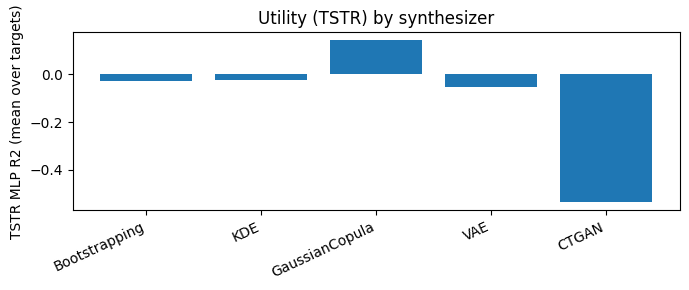

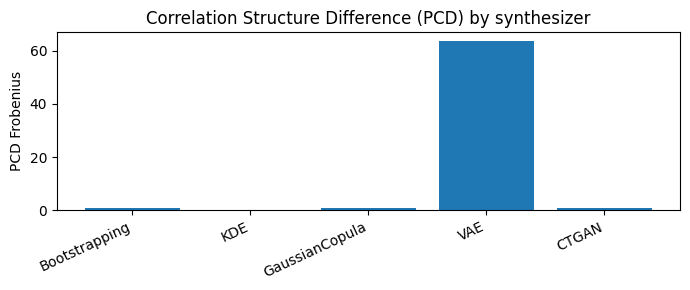

In [18]:

ok_df = results_df[results_df["status"] == "ok"].copy()
if len(ok_df) > 0:
    plt.figure(figsize=(7,3))
    plt.bar(ok_df["model"], ok_df["tstr_mlp_r2"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("TSTR MLP R2 (mean over targets)")
    plt.title("Utility (TSTR) by synthesizer")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,3))
    plt.bar(ok_df["model"], ok_df["pcd_fro"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("PCD Frobenius")
    plt.title("Correlation Structure Difference (PCD) by synthesizer")
    plt.tight_layout()
    plt.show()
else:
    print("No successful models to plot.")

## 9) (Optional) 설치 커맨드 셀
환경에 CTGAN/TabDDPM가 없으면 아래를 실행하세요.

```bash
pip install sdv
pip install synthcity
```

- SDV CTGAN은 GPU 사용이 데이터 전처리 후 epoch 학습 단계에서 보입니다.
- Synthcity TabDDPM은 `Plugins().get("ddpm", ...)`로 구동됩니다.